In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
from collections import Counter
import pandas as pd
import seaborn as sns
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
import psutil

# this generates samples of networks

In [2]:
random.seed(0)

In [3]:
Xs = []
Xs_labels = []

data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
counter = 0

for csv_file in data_dir.glob("*.csv"):
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    Xs_labels.append(csv_file.stem[:-5])
    X = np.column_stack([
        ws_pp['mentions'], #Relative mentions or mentions
        ws_pp['events'],
        ws_pp['avg_sentenceid'],
        ws_pp['avg_a1co'],
        ws_pp['avg_a2co'],
        ws_pp['avg_actco'],
        ws_pp['avg_raw_text'],
        ws_pp['avg_root_event'],
        ws_pp['avg_len'],
        ws_pp['avg_goldstein'],
        ws_pp['avg_tone'],
        ws_pp['avg_confidence'],
        ws_pp['avg_lat1'],
        ws_pp['avg_lon1'],
        ws_pp['avg_lat2'],
        ws_pp['avg_lon2'],
        ws_pp['avg_lata'],
        ws_pp['avg_lona'],
        ws_pp['total_num_mentions'],
        ws_pp['total_num_sources'],
        ws_pp['total_num_articles'],
    ])
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    Xs.append(X)

Xs = np.array(Xs)
print(Xs.shape)
#Xs = Xs[:50,:,:]
#Xs = Xs.transpose(1,2,0)[None, :, :, :]
#Xs = Xs[None, :, :, :]
#print(Xs.shape)

rng = np.random.default_rng(42)  # optional seed for reproducibility
n_instances = 200
subset_size = 5
subsets = []
for i in range(n_instances):
    idx = rng.choice(Xs.shape[0], size=subset_size, replace=False)
    subsets.append(Xs[idx])
subsets = np.stack(subsets)
print(subsets.shape)

(224, 489, 21)
(200, 5, 489, 21)


# no subsamples

In [4]:
Xs = []
Xs_labels = []

data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
counter = 0

for csv_file in data_dir.glob("*.csv"):
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    Xs_labels.append(csv_file.stem[:-5])
    X = np.column_stack([
        ws_pp['mentions'], #Relative mentions or mentions
        ws_pp['events'],
        ws_pp['avg_sentenceid'],
        ws_pp['avg_a1co'],
        ws_pp['avg_a2co'],
        ws_pp['avg_actco'],
        ws_pp['avg_raw_text'],
        ws_pp['avg_root_event'],
        ws_pp['avg_len'],
        ws_pp['avg_goldstein'],
        ws_pp['avg_tone'],
        ws_pp['avg_confidence'],
        ws_pp['avg_lat1'],
        ws_pp['avg_lon1'],
        ws_pp['avg_lat2'],
        ws_pp['avg_lon2'],
        ws_pp['avg_lata'],
        ws_pp['avg_lona'],
        ws_pp['total_num_mentions'],
        ws_pp['total_num_sources'],
        ws_pp['total_num_articles'],
    ])
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    Xs.append(X)

Xs = np.array(Xs)
print(Xs.shape)
all_Xs = Xs[None, :, :, :]
Xs = Xs[:15,:,:]
Xs = Xs[None, :, :, :]
print(Xs.shape)
subsets = Xs
all_Xs.shape

(224, 489, 21)
(1, 15, 489, 21)


(1, 224, 489, 21)

In [5]:
#X_train, X_temp = train_test_split(subsets,test_size=0.30,random_state=42,shuffle=True)
#X_valid, X_test = train_test_split(X_temp,test_size=0.50,random_state=42,shuffle=True)

X_train = subsets
X_valid = subsets
X_test = subsets

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(1, 15, 489, 21)
(1, 15, 489, 21)
(1, 15, 489, 21)


In [6]:
def save_data(X_train, X_valid, X_test):
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainFeatures.npy", X_train)
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validFeatures.npy", X_valid)
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testFeatures.npy", X_test)

    dummy_train = np.zeros(X_train.shape[0], dtype=np.int64)
    dummy_test = np.zeros(X_test.shape[0], dtype=np.int64)
    dummy_valid = np.zeros(X_valid.shape[0], dtype=np.int64)

    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainTargets.npy", dummy_train)
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validTargets.npy", dummy_valid)
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testTargets.npy", dummy_test)

    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainChangePoints.npy", dummy_train)
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validChangePoints.npy", dummy_valid)
    np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testChangePoints.npy", dummy_test)

In [7]:
eval.item().keys()

AttributeError: 'builtin_function_or_method' object has no attribute 'item'

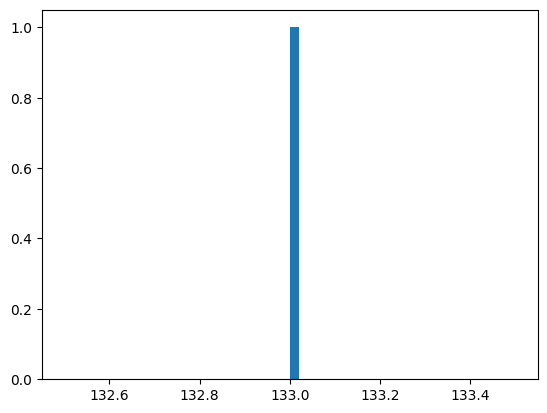

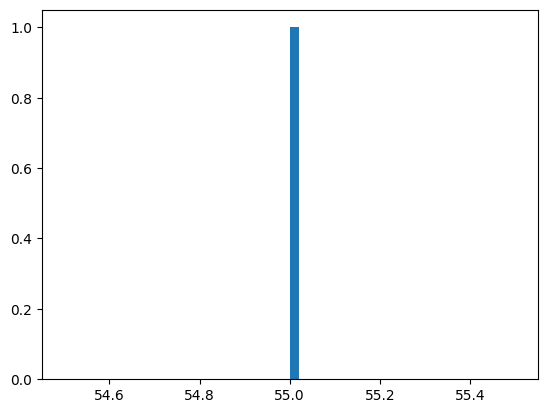

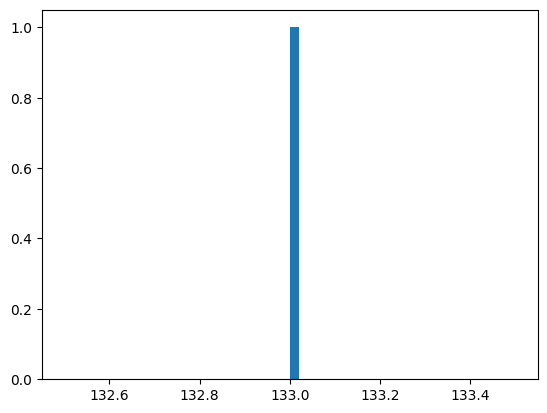

In [8]:
eval = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/exp/my_exp_rnn_gnn_real_data_more_epochs/gdelt_train_dict.npy", allow_pickle=True)
eval.item().keys()
plt.hist(eval.item()["pred_mse_cp"], bins=50, label="MSE")
plt.show()
plt.hist(eval.item()["pred_relation_cp"], bins=50, label="relation")
plt.show()
plt.hist(eval.item()["pred_combined_cp"], bins=50, label="combined")
plt.show()

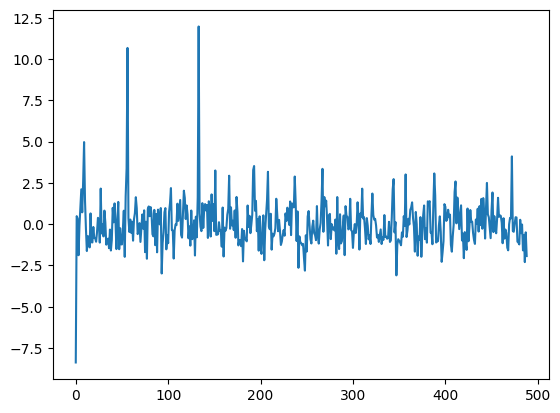

In [9]:
plt.plot(eval.item()["combined_score"][0])

## Documentation of Testing Times

| Number of Atoms | Runtime (s) | Peak Memory (MB) |
|----------------:|:-----------:|-----------------:|
| 5  | ~0.5 | ~400 |
| 10 | ~1.2 | ~900–1200 |
| 15 | ~1.8 | ~2000 |
| 20 | ~2.5–5 | ~1600–2900 |
| 25 | ~5–12 | — |
| 30 | ~10–18 | — |
| 35 | ~8–59 | — |
| 40 | ~94–149 | ~4000–5600 |

# GDELT on the clusters defined by k-means on ruptures

In [2]:
# k=20
cluster_labels = np.load("../../gdelt/clustering_results.npy")

In [3]:
import subprocess

In [ ]:
"""
for i in range(17, np.max(cluster_labels)+1):
    print(f"Cluster {i}: {np.sum(cluster_labels==i)} instances")
    subX = all_Xs[:, cluster_labels==i, :, :]
    print(subX.shape)
    X_train = subX
    X_test = subX
    X_valid = subX
    save_data(X_train, X_valid, X_test)
    num_atoms = subX.shape[1]
    print(f"Number of atoms: {num_atoms}")
    if num_atoms > 30:
        print(f"Skipping cluster {i} due to too many atoms")
        continue  
    if num_atoms < 2:
        print(f"Skipping cluster {i} due to too few atoms")
        continue  
    subprocess.run(["bash", "cmd.sh", "0", "test", f"my_exp_rnn_gnn_real_data_more_epochs", str(num_atoms)], cwd="C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD", check=True)
     #load results and save somewhere else
    results = np.load(f"exp/my_exp_rnn_gnn_real_data_more_epochs/gdelt_test_dict.npy", allow_pickle=True)
    np.save(f"C:/Users/cgl_0/OneDrive/Thesis/codes/results/cord_cpd/cluster_{i}.npy", results)
"""


Cluster 17: 1 instances
(1, 1, 489, 21)
Number of atoms: 1
Skipping cluster 17 due to too few atoms
Cluster 18: 4 instances
(1, 4, 489, 21)
Number of atoms: 4
Cluster 19: 8 instances
(1, 8, 489, 21)
Number of atoms: 8


In [6]:
for i in range(np.max(cluster_labels)+1):
    try:
        results = np.load(f"C:/Users/cgl_0/OneDrive/Thesis/codes/results/cord_cpd/cluster_{i}.npy", allow_pickle=True).item()
    except FileNotFoundError:
        print(f"Results for cluster {i} not found.")
        continue
    print(f"Change points for cluster {i}: {results['pred_combined_cp']}, MSE: {results['pred_mse_cp']}, Relation: {results['pred_relation_cp']}")

Change points for cluster 0: [208], MSE: [208], Relation: [117]
Change points for cluster 1: [56], MSE: [56], Relation: [293]
Change points for cluster 2: [26], MSE: [26], Relation: [113]
Change points for cluster 3: [369], MSE: [369], Relation: [424]
Change points for cluster 4: [60], MSE: [60], Relation: [319]
Change points for cluster 5: [223], MSE: [223], Relation: [109]
Change points for cluster 6: [58], MSE: [58], Relation: [38]
Change points for cluster 7: [118], MSE: [118], Relation: [89]
Change points for cluster 8: [103], MSE: [103], Relation: [95]
Change points for cluster 9: [337], MSE: [337], Relation: [42]
Change points for cluster 10: [402], MSE: [403], Relation: [441]
Change points for cluster 11: [29], MSE: [29], Relation: [55]
Change points for cluster 12: [68], MSE: [67], Relation: [363]
Change points for cluster 13: [44], MSE: [44], Relation: [153]
Results for cluster 14 not found.
Change points for cluster 15: [117], MSE: [117], Relation: [15]
Change points for clu